# Trabajo Final Ivan Zappalà

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import optuna
import time

from scipy import stats
from scipy.stats import pearsonr, kurtosis, skew, norm, probplot, boxcox_normmax
from scipy.special import boxcox1p

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_predict, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.exceptions import ConvergenceWarning

warnings.simplefilter("ignore", category=ConvergenceWarning)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.max_columns', 10)

# Workflow

---

## 1. Data Import
- Load dataset
- Check dataset shape and data types

---

## 2. Initial Exploratory Data Analysis (EDA)
- Descriptive statistics
- Identify missing values
- Visualize distributions
- Analyze preliminary correlations
- Detect outliers and anomalous patterns

---

## 3. Missing Values Analysis and Strategy
- Decide on strategy to handle missing values (drop, simple or advanced imputation)

---

## 4. Data Cleaning and Preprocessing
- Impute missing values 
- Transform categorical variables (ordinal encoding, one-hot encoding)
- Transform numerical variables (boxcox transform, scaling, normalization)
- Create new features (feature engineering)
- Handle outliers

---

## 5. Modeling
- Training and evaluating different models
- Feature Selection and Dimensionality reduction
- Hyperparameter fine tuning

---

## 6. Final Evaluation
- Evaluate the model on the test set

# 1) Loading the dataset
In this section we will load the full dataset, making some basic operations on it, like: <br>
-) **Merging the train dataset and the test dataset in one unique total dataset**<br>
-) **Check data types, shape of dataset, exploring the first rows of the dataset and the features names**

In [2]:
dataset_train = pd.read_csv("./house_prices/train.csv")
dataset_test = pd.read_csv("./house_prices/test.csv")
y_train=dataset_train.SalePrice
dataset_train.drop(["SalePrice"],axis=1,inplace=True)

In [3]:
dataset_full=pd.concat([dataset_train,dataset_test], axis=0, ignore_index=True)

In [4]:
print(dataset_train.shape)
print(dataset_test.shape)
print(dataset_full.shape)

(1460, 80)
(1459, 80)
(2919, 80)


## Shape of the dataset: number of samples and number of features

In [5]:
print(f"{dataset_full.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

### First five rows of the dataset

In [6]:
dataset_full.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,...,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,...,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,...,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,...,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,...,0,12,2008,WD,Normal


## 2. Initial Exploratory Data Analysis (EDA)
- Identify missing values
- Descriptive statistics
- Analyze target variable
- Analyze preliminary correlations: correlation matrix, heatmap
- Visualize distributions: histograms, boxplots, scatterplots
- Detect outliers


## Identifying missing values

In [9]:
#Calculating for each feature the percentage of missing values
all_feat_na = (dataset_full.isnull().sum() / dataset_full.shape[0]) * 100

#Dropping the rows where we have no missing values and sorting the values from the biggest to lowest
all_feat_na = all_feat_na.drop(all_feat_na[all_feat_na == 0].index).sort_values(ascending=False)
#Creating a dataframe containing the Missing Ratio for each feature
missing_data = pd.DataFrame({'Missing Ratio' : all_feat_na})
print(f"Number of features with missing values: {missing_data.shape[0]}")


Number of features with missing values: 34


### Visualizing the percentage of missing values

Text(0.5, 1.0, 'Percent missing data by feature')

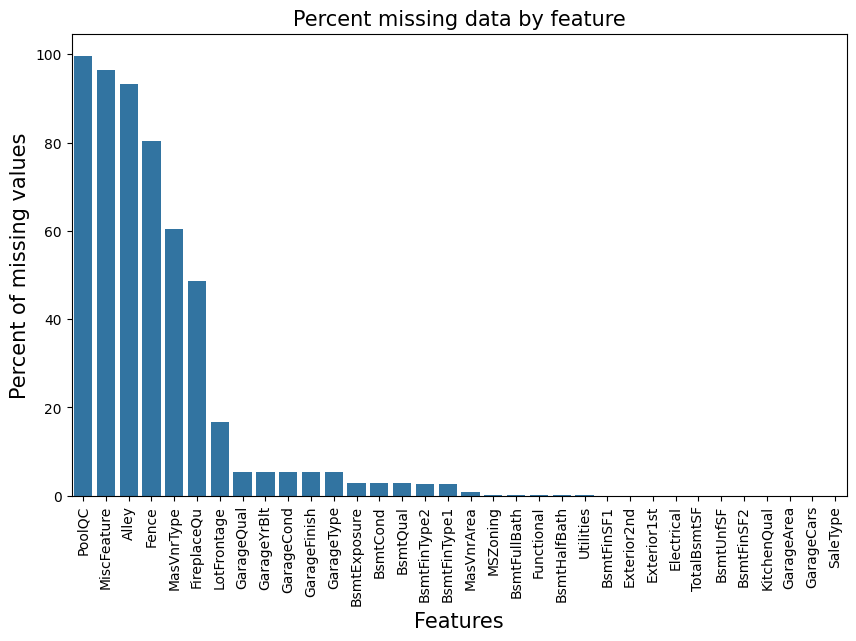

In [10]:
plt.figure(figsize=(10, 6))
plt.xticks(rotation=90)
sns.barplot(x=all_feat_na.index, y=all_feat_na)
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by feature', fontsize=15)

## Separating between numerical and categorical features

In [11]:
numerical_features = dataset_full.select_dtypes(exclude=["object"]).columns.tolist()
categorical_features = dataset_full.select_dtypes(include=["object"]).columns.tolist()

if "SalePrice" in numerical_features:
    numerical_features.remove("SalePrice")

print(f"{len(numerical_features)} Numerical Features\n{len(categorical_features)} Categorical Features")

37 Numerical Features
43 Categorical Features


### Descriptive statistics

In [12]:
interesting_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea',
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
    'GarageArea', 'GarageCars',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea',
    'OverallQual', 'OverallCond',
    'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd'
]

dataset_full[interesting_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LotFrontage,2433.0,69.305795,23.344905,21.0,59.0,68.0,80.0,313.0
LotArea,2919.0,10168.114080,7886.996359,1300.0,7478.0,9453.0,11570.0,215245.0
MasVnrArea,2896.0,102.201312,179.334253,0.0,0.0,0.0,164.0,1600.0
TotalBsmtSF,2918.0,1051.777587,440.766258,0.0,793.0,989.5,1302.0,6110.0
1stFlrSF,2919.0,1159.581706,392.362079,334.0,876.0,1082.0,1387.5,5095.0
2ndFlrSF,2919.0,336.483727,428.701456,0.0,0.0,0.0,704.0,2065.0
GrLivArea,2919.0,1500.759849,506.051045,334.0,1126.0,1444.0,1743.5,5642.0
GarageArea,2918.0,472.874572,215.394815,0.0,320.0,480.0,576.0,1488.0
GarageCars,2918.0,1.766621,0.761624,0.0,1.0,2.0,2.0,5.0
WoodDeckSF,2919.0,93.709832,126.526589,0.0,0.0,0.0,168.0,1424.0


## Descriptive Statistics Observations

### 1. Lot Size and Floor Area

- **LotFrontage**: Mean ~69, max = 313 → potential outlier.
- **LotArea**: Mean = 10,168, max = 215,245 → extreme outlier present. Strongly right-skewed distribution.
- **MasVnrArea**: 25th and 50th percentiles = 0 → most houses have no masonry veneer, but some go up to 1600.
- **TotalBsmtSF**, **1stFlrSF**, **2ndFlrSF**, **GrLivArea**:
  - Wide ranges with some high values over 5000 → possible outliers.
  - `2ndFlrSF`: 25% and 50% = 0 → many houses have no second floor.
  - `GrLivArea`: Mean = 1500, max = 5642 → potential outliers.

---

### 2. Garage and Exterior Features

- **GarageArea**, **GarageCars**:
  - `GarageCars` is centered around 2 (median and 75th percentile), max = 5 → potential outliers.
- **WoodDeckSF**, **OpenPorchSF**, **EnclosedPorch**, **PoolArea**, **MiscVal**:
  - Many zeros.
  - `EnclosedPorch` and `PoolArea` have 75th percentile = 0 → most houses don't have these features.
  - `PoolArea`: Mean = 2.25, max = 800 → very right-skewed.

---

### 3. Quality and Condition

- **OverallQual**: Mean = 6.09, median = 6 → well-centered distribution with useful variability. Likely a strong predictor.
- **OverallCond**: More concentrated around 5–6 → less variation than `OverallQual`.

---

### 4. Bathrooms and Room Counts

- **FullBath**: Median = 2 → reasonable distribution.
- **HalfBath**: Median = 0, 75th percentile = 1 → many houses without half baths.

---


### Final Notes

#### Features with many zeros or skewed distributions:
- `MasVnrArea`, `2ndFlrSF`, `PoolArea`, `MiscVal`, `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`

These might benefit from:
- **transformations** to reduce skewness.
- **Binarization** to capture presence/absence.

#### Potential outliers to investigate:
- `LotArea`
- `GrLivArea`
- `TotRmsAbvGrd`
- `PoolArea`


In [13]:
for cat_feat in categorical_features:
    print(dataset_full[cat_feat].value_counts())

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64
Street
Pave    2907
Grvl      12
Name: count, dtype: int64
Alley
Grvl    120
Pave     78
Name: count, dtype: int64
LotShape
Reg    1859
IR1     968
IR2      76
IR3      16
Name: count, dtype: int64
LandContour
Lvl    2622
HLS     120
Bnk     117
Low      60
Name: count, dtype: int64
Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64
LotConfig
Inside     2133
Corner      511
CulDSac     176
FR2          85
FR3          14
Name: count, dtype: int64
LandSlope
Gtl    2778
Mod     125
Sev      16
Name: count, dtype: int64
Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veen

## Analyzing target variable

In [14]:
y_train.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

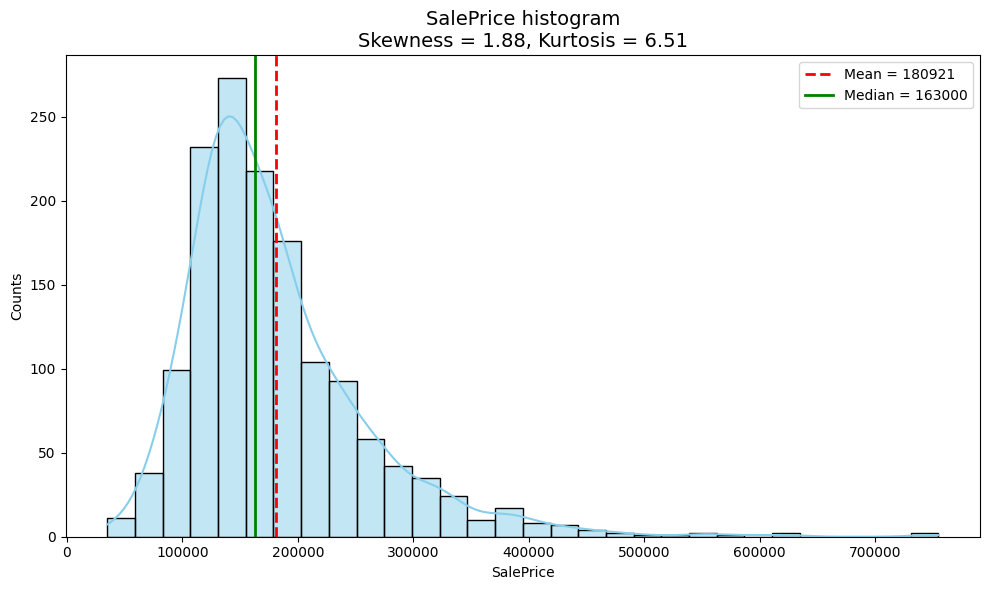

In [16]:
#Statistical quantites
y_mean = y_train.mean()
y_median = y_train.median()
y_kurtosis = kurtosis(y_train, fisher=True)
y_skew = skew(y_train)

# Plotting
plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True, bins=30, color="skyblue")

# Plotting mean and median vertical lines
plt.axvline(y_mean, color='red', linestyle='--', linewidth=2, label=f"Mean = {y_mean:.0f}")
plt.axvline(y_median, color='green', linestyle='-', linewidth=2, label=f"Median = {y_median:.0f}")


plt.title(f"SalePrice histogram\nSkewness = {y_skew:.2f}, Kurtosis = {y_kurtosis:.2f}", fontsize=14)

plt.xlabel("SalePrice")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()

### Observations on Target Variable Distribution

From both the histogram and the computed statistical values, we observe that the target variable does **not follow a normal distribution**:

- The **distribution is skewed** (as shown by the skewness value)
- The **kurtosis is significantly different** from that of a normal distribution
- The data shows a **long right tail** and concentration toward lower values

Therefore, it is advisable to apply a **logarithmic transformation** to normalize the distribution before training regression models.


## Analyzing preliminary correlation

In [17]:
df_corr=dataset_full.copy()
df_corr["SalePrice"]=y_train
correlation_matrix = df_corr[numerical_features + ["SalePrice"]].corr()
correlation_matrix['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

<Axes: >

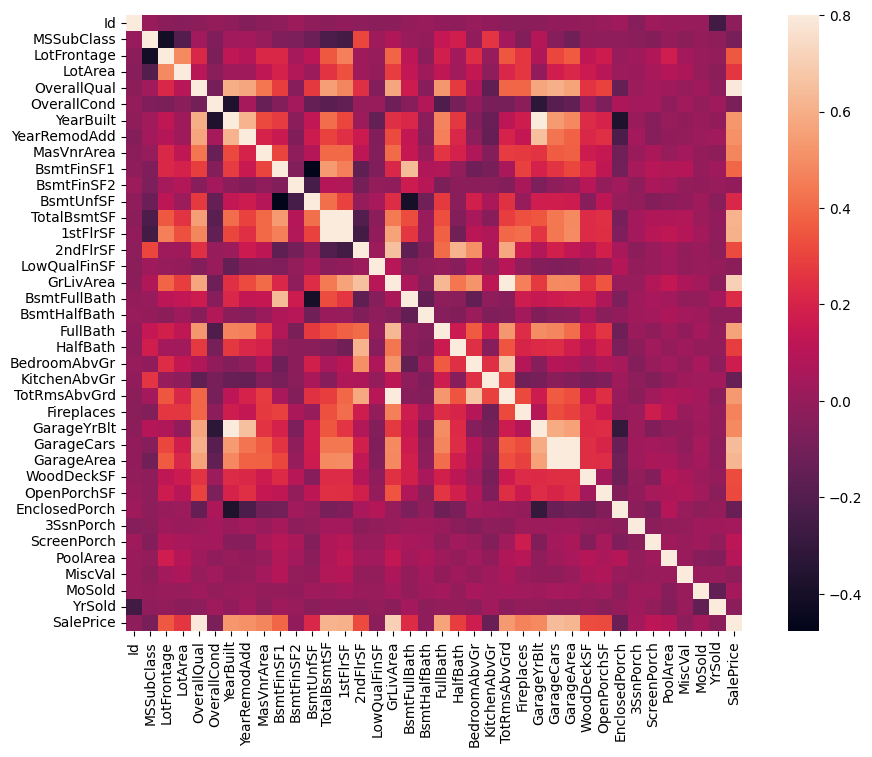

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, vmax=.8, square=True)

## Multicollinearity and PCA

Some features in the dataset appear to be highly correlated, which may lead to the issue of **multicollinearity**. This can negatively impact the stability and interpretability of a regression model.

From the correlation analysis, the following groups of features seem to be strongly correlated:

- **Garage-related features**:
  - `GarageYrBlt`, `GarageCars`, `GarageArea`
- **Year-related features**:
  - `GarageYrBlt`, `YearBuilt`
- **Basement and floor size features**:
  - `TotalBsmtSF`, `1stFlrSF`
- **Lot size features**:
  - `LotArea`, `LotFrontage`

We will deal with that in the following via Feature Selection and Dimensionality Reduction

## Visualizing graphs and distributions of some important features correlated with the target one

### Plotting Overall Quality vs Sale price

Text(0, 0.5, 'Sale Price')

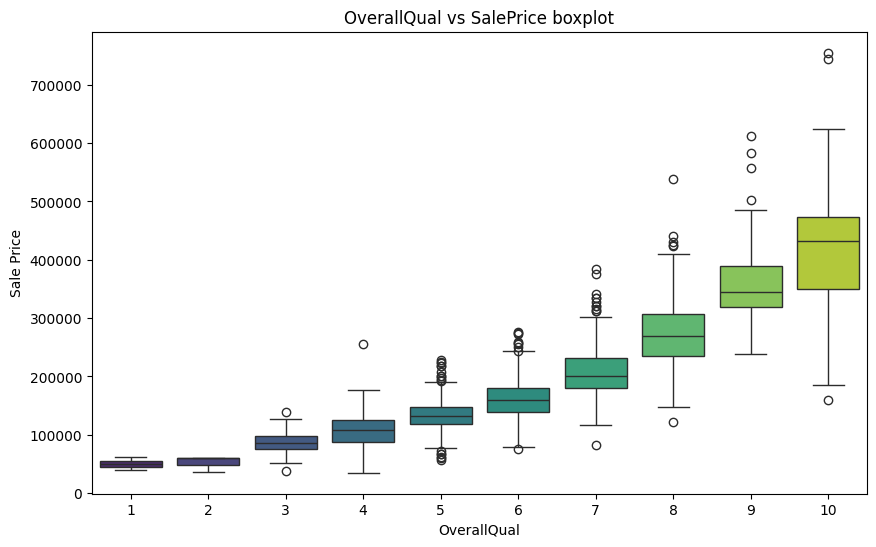

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x="OverallQual",y=y_train,data=dataset_full,palette="viridis")
plt.title("OverallQual vs SalePrice boxplot")
plt.xlabel("OverallQual")
plt.ylabel("Sale Price")

### Plotting GrLivArea vs Sale price

Text(0, 0.5, 'Sale Price')

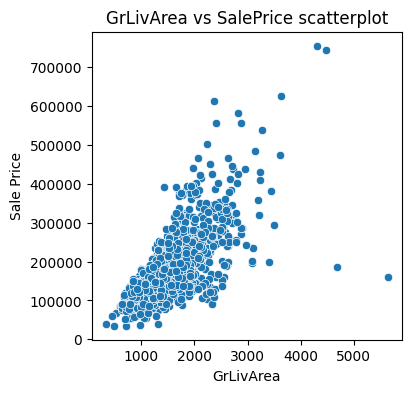

In [21]:
plt.figure(figsize=(4,4))
sns.scatterplot(x="GrLivArea",y=y_train,data=dataset_full)
plt.title("GrLivArea vs SalePrice scatterplot")
plt.xlabel("GrLivArea")
plt.ylabel("Sale Price")

### Plotting GarageCars vs Sale price

Text(0, 0.5, 'Sale Price')

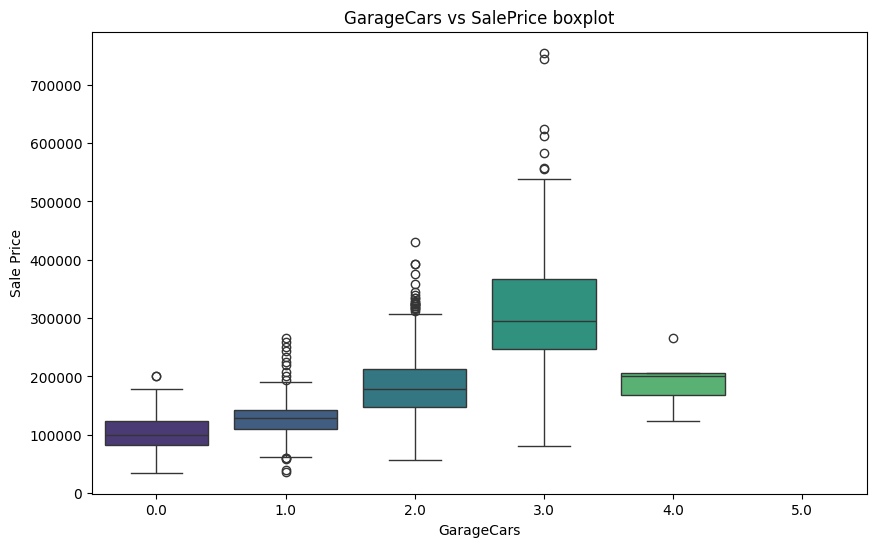

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x="GarageCars",y=y_train,data=dataset_full,palette="viridis")
plt.title("GarageCars vs SalePrice boxplot")
plt.xlabel("GarageCars")
plt.ylabel("Sale Price")

### Plotting Neighborhood vs Sale price

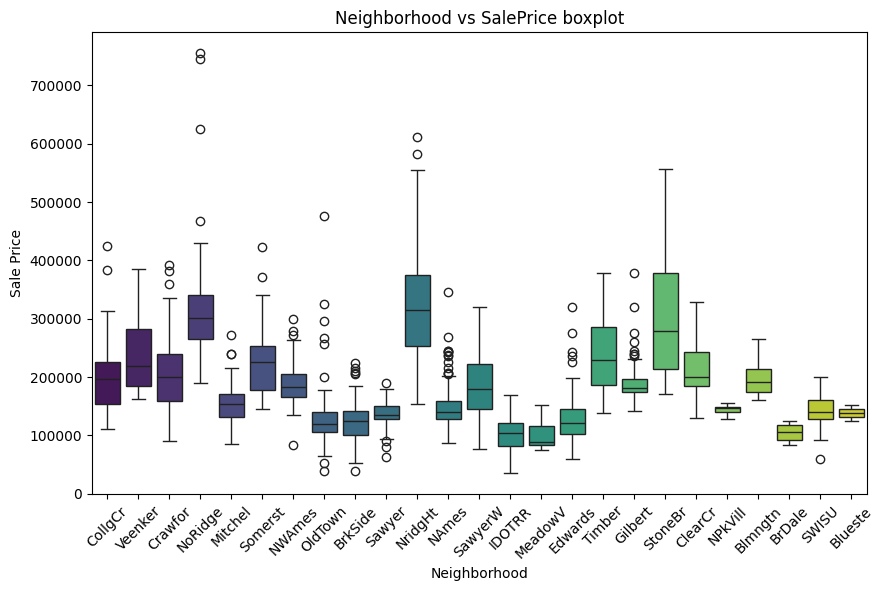

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Neighborhood",y=y_train,data=dataset_full,palette="viridis")
plt.title("Neighborhood vs SalePrice boxplot")
plt.xlabel("Neighborhood")
plt.ylabel("Sale Price")
plt.xticks(rotation=45);

### Plotting YearBuilt vs Sale price

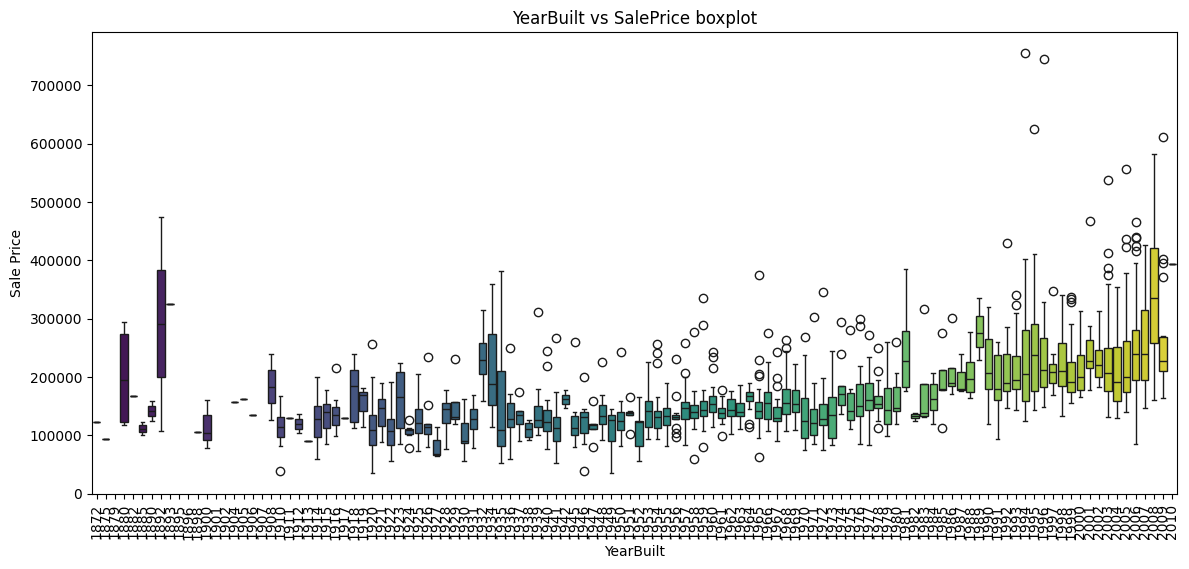

In [24]:
plt.figure(figsize=(14,6))
sns.boxplot(x="YearBuilt",y=y_train,data=dataset_full,palette="viridis")
plt.title("YearBuilt vs SalePrice boxplot")
plt.xlabel("YearBuilt")
plt.ylabel("Sale Price")
plt.xticks(rotation=90);

### Pairplotting the first n most correlated features with SalePrice

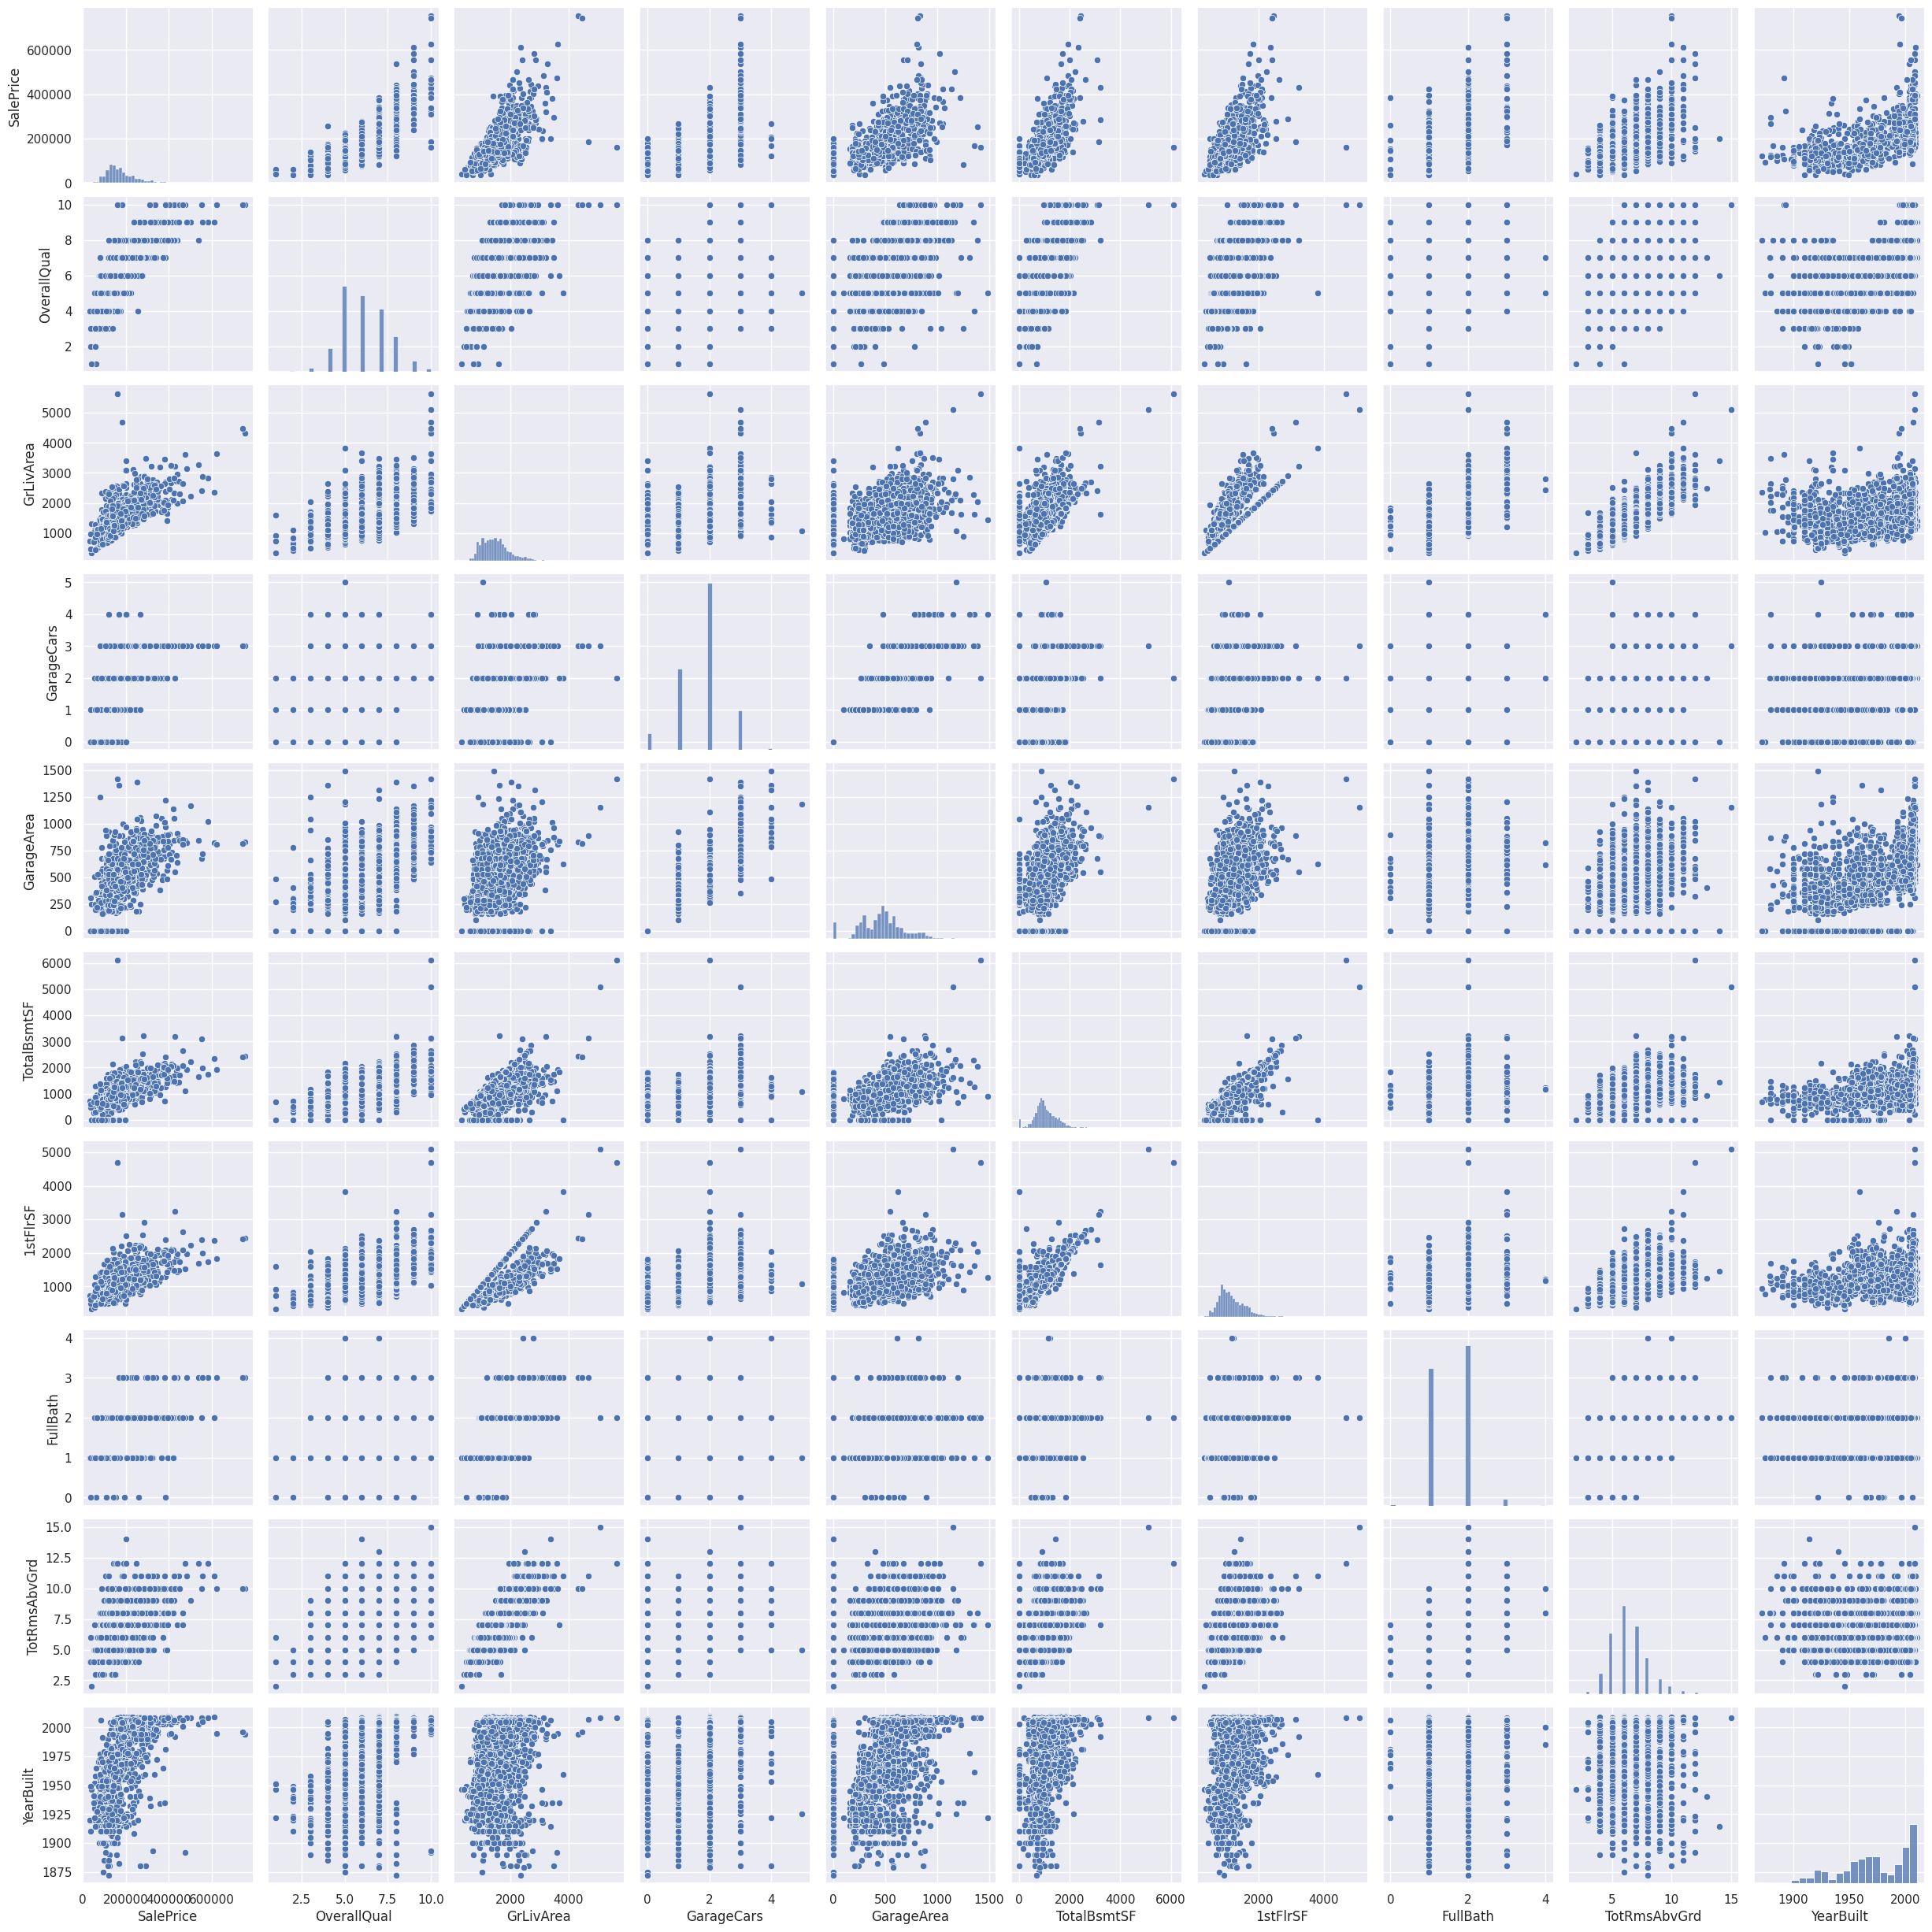

In [25]:
sns.set()
#Selecting the first n features more correlated with SalePrice and pairplotting them
n=10
cols = correlation_matrix["SalePrice"].sort_values(ascending=False).index[:n]
sns.pairplot(df_corr[cols], size = 2.5)
plt.show();

# 3. Data Cleaning and Feature Engineering
- Handle outliers
- Impute missing values
- Create new features
- Transform categorical variables (ordinal encoding, one-hot encoding)
- Transform numerical variables (boxcox transformation, scaling)

## Handling Outliers

#### Outlier Detection Strategy

To determine which outliers should be removed from the dataset, we will analyze the **first row of the pairplot** shown above.

This row displays scatterplots between the **target variable** and the **top 10 features most correlated** with it. By visually inspecting these plots, we can identify extreme values or unusual patterns that deviate significantly from the general trend.

These outliers, if not handled, could negatively affect model training and lead to poor generalization. Therefore, we will consider removing them based on this visual analysis.


In [33]:
print(dataset_train.shape,y_train.shape)

(1458, 80) (1458,)


In [34]:
GrLivArea_to_drop=dataset_train[(dataset_train['GrLivArea'] > 4000) & (y_train < 300000)].index.tolist()
TotalBsmtSf_to_drop=dataset_train[(dataset_train['TotalBsmtSF'] > 4000) & (y_train < 200000)].index.tolist()
index_to_drop=list(set(GrLivArea_to_drop+TotalBsmtSf_to_drop)) #We do this to have a list of unique values
dataset_train = dataset_train.drop(index_to_drop)
y_train=y_train.drop(index_to_drop)

In [35]:
print(dataset_train.shape,y_train.shape)

(1458, 80) (1458,)


In [36]:
dataset_full=pd.concat([dataset_train,dataset_test], axis=0, ignore_index=True)

In [37]:
n_samples_train=dataset_train.shape[0]
X=dataset_full[:n_samples_train]

# Data Preprocessing Summary

The function `make_preprocessing(X)` performs a comprehensive series of preprocessing steps on the dataset. Here's a breakdown of the operations applied:

### 1. Handling Missing Values
- **Replace with `"None"`** for features where absence indicates non-existence (e.g., no pool, no garage):
  - `Alley`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `PoolQC`, `Fence`, `MiscFeature`, `MasVnrType`
  
- **Replace with mode (most frequent value)** for categorical variables:
  - `Electrical`, `MSZoning`, `KitchenQual`, `Exterior1st`, `Exterior2nd`, `SaleType`
  
- **Replace with `0`** for numerical features where absence means zero:
  - `MasVnrArea`, `GarageYrBlt`, `BsmtHalfBath`, `BsmtFullBath`, `BsmtFinSF1`, `BsmtFinSF2`, `TotalBsmtSF`, `BsmtUnfSF`, `GarageCars`, `GarageArea`
  
- **Replace with `"Typical"`** for:
  - `Functional`
  
- **Group-based imputation**:
  - `LotFrontage` is imputed with the **median value per Neighborhood**.

### 2. Drop Redundant Columns
- The `Utilities` column is removed from the dataset.

### 3. Encoding Categorical Variables
- **Ordinal Encoding** for features with a meaningful order, using predefined category orderings (e.g., `ExterQual`, `BsmtCond`, etc.).
- **One-Hot Encoding** for nominal (unordered) categorical features (e.g., `MSZoning`, `Street`, `Neighborhood`, etc.).

### 4. Transformation and Scaling
- **Numerical features** are:
  - Transformed using Box-Cox for skewed distributions (if skewness > 1.0),
  - Then scaled using `RobustScaler` to reduce the impact of outliers.

### 5. Feature Engineering
- **New combined features** are created:
  - `TotalSF` = `TotalBsmtSF` + `1stFlrSF` + `2ndFlrSF`
  - `TotBath` = sum of full and half baths (with 0.5 weight for half baths)
  - `PorchTotalSF` = sum of all porch-related features
  - `OverallScore` = weighted average of `OverallQual` and `OverallCond`
  - `ExterScore` = weighted average of `ExterQual` and `ExterCond`
  - `BsmtScore` = weighted average of `BsmtQual` and `BsmtCond`
  - `GarageScore` = weighted average of `GarageQual` and `GarageCond`

### 6. Final Feature Pruning
- Original variables used to compute new engineered features are dropped:
  - e.g., `TotalBsmtSF`, `1stFlrSF`, `OverallQual`, `GarageCond`, etc.
- Also, the `Id` column is dropped.

The final processed dataset is returned as a pandas DataFrame, ready for modeling.


In [38]:
#Features to replace with "None"
replace_with_none=["Alley","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2",
                     "FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","PoolQC",
                     "Fence","MiscFeature","MasVnrType"]
#Features to replace with mode
replace_with_mode = ["Electrical", "MSZoning", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType"]
#Features to replace with 0
replace_with_zero=["MasVnrArea","GarageYrBlt","BsmtHalfBath","BsmtFullBath","BsmtFinSF1","BsmtFinSF2",
                   "TotalBsmtSF","BsmtUnfSF","GarageCars","GarageArea"]# 4. LotFrontage: Filling with median per Neighborhood
replace_by_group = ["LotFrontage"]
#Functional: Fill with "Typical"
replace_with_typical = ["Functional"]

#List of ordinal categorical features (with meaningful order)
ordinal_features=["LotShape","LandContour","LandSlope","ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC",
                  "KitchenQual","FireplaceQu","GarageQual","GarageCond","PoolQC"]
#List of nominal categorical features (unordered categories)
nominal_features=["MSZoning","Street","Alley","LotConfig","Neighborhood","Condition1","Condition2",
                  "BldgType","HouseStyle","RoofStyle","RoofMatl","Exterior1st","Exterior2nd","MasVnrType",
                  "Foundation","BsmtExposure","BsmtFinType1","BsmtFinType2","Heating","CentralAir","Electrical",
                  "Functional","GarageType","GarageFinish","PavedDrive","Fence","MiscFeature","SaleType",
                  "SaleCondition"]

# Ordering for each ordinal feature (used by OrdinalEncoder)
ordinal_orderings = {
    'LotShape': ['Reg', 'IR1', 'IR2', 'IR3'],            
    'LandContour': ['Lvl', 'Bnk', 'HLS', 'Low'],         
    'LandSlope': ['Gtl', 'Mod', 'Sev'],                  
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],         
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],         
    'BsmtQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],  
    'BsmtCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],  
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],         
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],       
    'FireplaceQu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], 
    'GarageQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],  
    'GarageCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],  
    'PoolQC': ['None', 'Po', 'Fa', 'Gd', 'Ex']            
}

In [39]:
# Custom transformer that fills missing values in a column using the median value of a specified group
class GroupMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, group_col, target_col):
        self.group_col = group_col #column used to group rows (In our case: Neighborhood)
        self.target_col = target_col #column with missing values to impute (In our case: LotFrontage)

    def fit(self, X, y=None):
        # Calculate the median of the target column for each group
        self.group_medians_ = X.groupby(self.group_col)[self.target_col].median()
        
        # Store the input feature names for consistency later
        self.feature_names_in_ = X.columns
        return self

    def transform(self, X):
        # Create a copy to avoid modifying the original dataframe
        X = X.copy()

        # Define an internal function to impute missing values row-wise
        def impute(row):
            if pd.isnull(row[self.target_col]):
                # If the value is missing, use the group's median; if the group is not in training set, return NaN
                return self.group_medians_.get(row[self.group_col], np.nan)
            else:
                # If the value is present, keep it
                return row[self.target_col]

        # Apply the imputation function to each row
        X[self.target_col] = X.apply(impute, axis=1)
        return X

    def get_feature_names_out(self, input_features=None):
        # Return original feature names (used for compatibility with pipelines and ColumnTransformer)
        if input_features is None:
            return self.feature_names_in_
        return input_features


In [40]:
# Custom transformer that applies Box-Cox transformation to numeric features with high skewness
class BoxCoxSkewedTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=1.0, lmbda=0):
        # skew_threshold: absolute skewness above which features will be transformed
        # lmbda: default lambda value for Box-Cox, used if optimization fails
        self.skew_threshold = skew_threshold
        self.skewed_features_ = []  # stores the names of skewed features
        self.lmbda = lmbda

    def fit(self, X, y=None):
        # Convert to DataFrame to ensure named columns
        X = pd.DataFrame(X, dtype=float)
        self.feature_names_in_ = X.columns

        # Calculate absolute skewness for each feature
        cols_skew = X.apply(lambda col : abs(col.skew()), axis=0)

        # Identify features with skewness above the threshold
        self.skewed_features_ = cols_skew[cols_skew > self.skew_threshold].index
        
        return self

    def transform(self, X):
        # Ensure X is a DataFrame with correct column names and float dtype
        X = pd.DataFrame(X, columns=self.feature_names_in_, dtype=float)
        X = X.copy()

        # Apply Box-Cox transformation only to the previously identified skewed features
        for feat in self.skewed_features_:
            x = X[feat]

            # Skip transformation if feature has NaNs, only one unique value, or invalid range
            if (x.isnull().any()) or (x.nunique() <= 1) or ((x + 1).min() <= 0):
                print(f"Skipping {feat}")
                continue

            try:
                # Find optimal lambda for Box-Cox transformation using maximum likelihood
                lambda_opt = boxcox_normmax(x + 1)
                # Apply Box-Cox transformation with the optimal lambda (using x + 1 to avoid 0 or negative values)
                X[feat] = boxcox1p(x, lambda_opt)
            except Exception as e:
                # If the transformation fails, log the error and transform the feature with a predetermine lambda value
                print(f"Box-Cox failed for {feat}: {e}")
                X[feat] = boxcox1p(x, self.lmbda)
        return X

    def get_feature_names_out(self, input_features=None):
        
        return input_features if input_features is not None else self.feature_names_in_


In [41]:
def make_preprocessing(X):
    # 1. Define imputers for different missing data strategies:
    #    - imputer_mode: replaces missing with most frequent value
    #    - imputer_none: replaces missing with string "None"
    #    - imputer_zero: replaces missing with 0
    #    - imputer_typical: replaces missing with string "Typical"
    #    - imputer_group: custom imputer filling LotFrontage by median per Neighborhood group
    imputer_mode = SimpleImputer(strategy='most_frequent')
    imputer_none = SimpleImputer(strategy='constant', fill_value="None")
    imputer_zero = SimpleImputer(strategy='constant', fill_value=0)
    imputer_typical = SimpleImputer(strategy='constant', fill_value="Typical")
    imputer_group = GroupMedianImputer(group_col="Neighborhood" , target_col="LotFrontage")
    
    # 2. Compose column transformer to apply different imputers to specified feature sets
    impute = ColumnTransformer([("mode",imputer_mode,replace_with_mode),
                                ("const_none",imputer_none,replace_with_none),
                                ("const_zero",imputer_zero,replace_with_zero),
                                ("const_typical",imputer_typical,replace_with_typical)
                               ],remainder="passthrough")

    # 3. Create pipeline to first apply group-based median imputation then general imputations
    pipeline = Pipeline([
        ("group_t", imputer_group),
        ("imputer", impute)
    ])

    # 4. Fit the pipeline on X and transform the data accordingly
    X_1 = pipeline.fit_transform(X)

    # 5. Extract clean column names from pipeline output for creating a DataFrame
    col_names = pipeline.get_feature_names_out()
    names = list(map(lambda name: name.split("__")[1], col_names))
    X_1_df = pd.DataFrame(X_1, columns=names)

    # 6. Drop 'Utilities' column as it has little variance or is not useful for modeling
    X_1_df.drop("Utilities", axis=1, inplace=True)    
    
    # 7. Prepare encoders for categorical and numerical features:
    #    - ordinal_encoder: encodes ordinal features with predefined orderings
    #    - onehot_encoder: encodes nominal categorical features with one-hot encoding
    #    - numeric_transformer: applies Box-Cox transformation to reduce skewness, then scales numerics

    ordinal_categories = [ordinal_orderings[col] for col in ordinal_features]
    ordinal_encoder = OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1)
    
    ordinal_transformer = Pipeline([("ordinal_enc", ordinal_encoder),
                                    ("scaler", RobustScaler())
                                   ])
    
    onehot_encoder=OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    numeric_transformer = Pipeline([('boxcox', BoxCoxSkewedTransformer(skew_threshold=1.0)),
                                    ('scaler', RobustScaler())
                                   ])
    # 8. ColumnTransformer applies:
    #    - ordinal encoding and RobustScaling on ordinal features
    #    - one-hot encoding on nominal features
    #    - numeric transformation on numerical features
    encoder = ColumnTransformer([("ordinal", ordinal_transformer, ordinal_features),
                                 ("onehot", onehot_encoder, nominal_features),
                                 ("scaling",numeric_transformer,numerical_features)
                                ],remainder="passthrough")
    
    # 9. Fit the encoder and transform the imputed dataframe
    X_2 = encoder.fit_transform(X_1_df)

    # 10. Extract new column names after encoding and create a DataFrame with float dtype
    col_names = encoder.get_feature_names_out()
    names = list(map(lambda name: name.split("__")[1], col_names))
    X_2_df = pd.DataFrame(X_2, columns=names, dtype=float)
    
    
    # 11. Create new combined features to summarize important information:
    #     - TotalSF: total square footage combining basement and floors
    #     - TotBath: total bathrooms including full and half baths (half baths weighted 0.5)
    #     - PorchTotalSF: total porch area combining multiple porch types
    X_2_df["TotalSF"] = X_2_df["TotalBsmtSF"] + X_2_df["1stFlrSF"] + X_2_df["2ndFlrSF"]
    X_2_df["TotBath"] = X_2_df["BsmtFullBath"] + X_2_df["FullBath"] + 0.5 * (X_2_df["BsmtHalfBath"] + X_2_df["HalfBath"])
    X_2_df["PorchTotalSF"] = X_2_df["OpenPorchSF"] + X_2_df["EnclosedPorch"] + X_2_df["3SsnPorch"] + X_2_df["ScreenPorch"]

    # 12. Create composite quality/condition scores by weighted average of related features
    X_2_df["OverallScore"] = (X_2_df["OverallQual"] * 0.7 + X_2_df["OverallCond"] * 0.3)
    X_2_df["ExterScore"] = (X_2_df["ExterQual"] * 0.7 + X_2_df["ExterCond"] * 0.3)
    X_2_df["BsmtScore"] = (X_2_df["BsmtQual"] * 0.7 + X_2_df["BsmtCond"] * 0.3)
    X_2_df["GarageScore"] = (X_2_df["GarageQual"] * 0.7 + X_2_df["GarageCond"] * 0.3)

    # 13. Drop original features that are now summarized or redundant to avoid multicollinearity and reduce dimensionality
    to_drop = [
        "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",  # combined in TotalSF
        "BsmtFullBath", "FullBath", "BsmtHalfBath", "HalfBath",  # combined in TotBath
        "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",  # combined in PorchTotalSF
        "OverallQual", "OverallCond", "ExterQual", "ExterCond",
        "BsmtQual", "BsmtCond", "GarageQual", "GarageCond",
        "Id"
    ]
    X_2_df = X_2_df.drop(columns=to_drop)

    return X_2_df

In [42]:
data = make_preprocessing(dataset_full)

Box-Cox failed for LotArea: The algorithm terminated without finding a valid bracket. Consider trying different initial points.
Box-Cox failed for 1stFlrSF: The algorithm terminated without finding a valid bracket. Consider trying different initial points.


In [43]:
X=data[:n_samples_train]
X_sub = data[n_samples_train:]
print(X.shape)
print(X_sub.shape)

(1458, 240)
(1459, 240)


# Target Variable log transformation

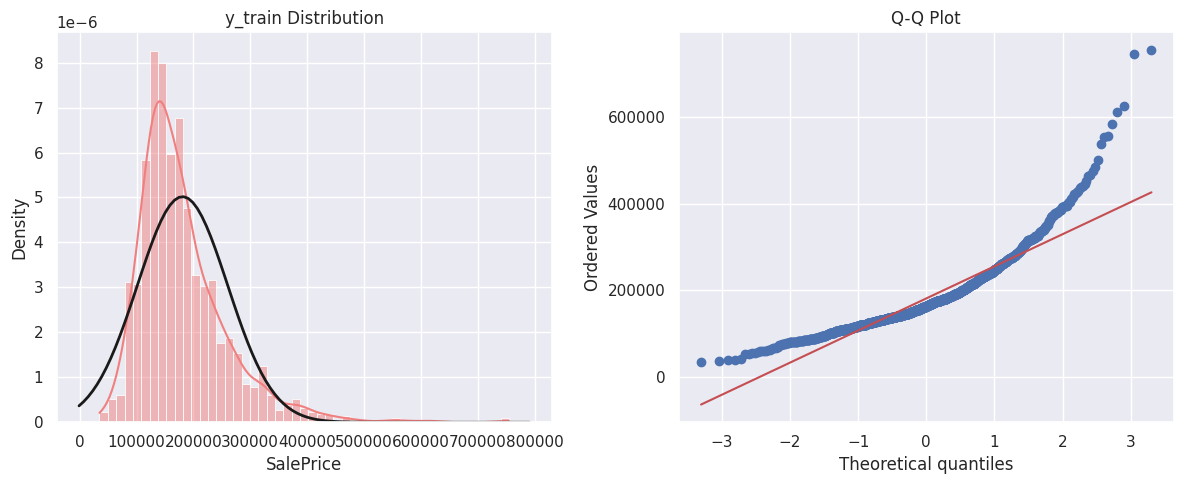

In [44]:
# Create a figure for containing two plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram of y_train with a KDE curve on the first axis
sns.histplot(y_train, kde=True, stat="density", ax=axes[0], color="lightcoral")

# Get x-axis limits from the histogram plot
xmin, xmax = axes[0].get_xlim()
# Generate 100 points between xmin and xmax for plotting the normal distribution curve
x = np.linspace(xmin, xmax, 100)

# Calculate the normal probability density function (PDF) using mean and std of y_train
p = norm.pdf(x, y_train.mean(), y_train.std())
# Overlay the normal distribution curve on the histogram
axes[0].plot(x, p, 'k', linewidth=2)
# Set the title for the histogram plot
axes[0].set_title("y_train Distribution")

# Generate a Q-Q plot comparing y_train quantiles to a normal distribution on the second axis
probplot(y_train, dist="norm", plot=axes[1])

axes[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()


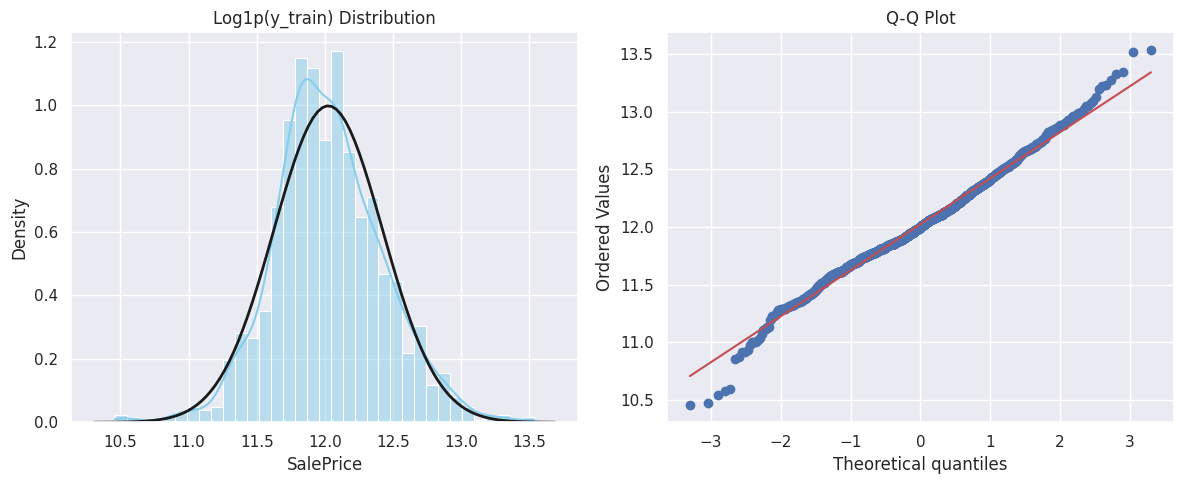

In [45]:
# Apply log1p transformation to y_train to reduce skewness
y_train = np.log1p(y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot histogram of the transformed y_train with KDE curve on the first axis
sns.histplot(y_train, kde=True, stat="density", ax=axes[0], color="skyblue")

xmin, xmax = axes[0].get_xlim()

x = np.linspace(xmin, xmax, 100)

# Calculate the normal probability density function (PDF) using mean and std of transformed y_train
p = norm.pdf(x, y_train.mean(), y_train.std())
axes[0].plot(x, p, 'k', linewidth=2)

axes[0].set_title("Log1p(y_train) Distribution")

# Generate a Q-Q plot comparing transformed y_train quantiles to a normal distribution on the second axis
probplot(y_train, dist="norm", plot=axes[1])

axes[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()


#### Effect of Logarithmic Transformation on Target Variable Distribution

Applying a logarithmic transformation (`log1p`) to the target variable helps to stabilize its variance and reduce skewness. 

As a result, the transformed target variable tends to follow a distribution that is closer to normal (Gaussian). This is beneficial for many machine learning models that assume or perform better when the target variable is approximately normally distributed.

The following plots illustrate this effect:

- The histogram with the overlaid normal density curve shows how the distribution of the log-transformed target aligns well with a normal distribution.
- The Q-Q plot confirms the improved normality by showing points closely following the diagonal reference line.


# Models to train:
Lasso, Ridge, ElasticNet, GradientBoostingRegresson, XGBoost, SVR

In [35]:
y=y_train

In [36]:
print(X.shape)
print(y.shape)

(1458, 240)
(1458,)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=1/3,random_state=100)

In [38]:
print(X_train.shape, X_test.shape)

(972, 240) (486, 240)


In [39]:
models_to_grid = {
    "Lasso": {
        "model": Lasso(random_state=1),
        "params": {
            'alpha': [10**i for i in range(-5, 1)]
        }
    },
    "Ridge": {
        "model": Ridge(random_state=2),
        "params": {
            'alpha': [10**i for i in range(-4, 4)],
            'solver': ['auto', 'svd', 'cholesky', 'lsqr']
        }
    },
    "Elastic Net": {
        "model": ElasticNet(max_iter=10000, random_state=3),
        "params": {
            'alpha': [10**i for i in range(-4, 1)],
            'l1_ratio': np.random.uniform(0, 1, 30)
        }
    },
    "Decision Tree Regressor": {
        "model": DecisionTreeRegressor(random_state=4),
        "params": {
            'criterion': ['squared_error', 'absolute_error', 'poisson'],
            'splitter': ['best', 'random'],
            'max_depth': [None, 5, 10,  30],
            'min_samples_split': [2, 10],
            'min_samples_leaf': [1, 4],
            'max_features': ['auto', 'sqrt', 'log2'],
            'max_leaf_nodes': [None, 10, 20,  50],
            'min_impurity_decrease': [0.0, 0.01,  0.1]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            'kernel' : ['linear','poly','rbf','sigmoid'],
            'C': [10**i for i in range (-3,3)],
            'epsilon':np.random.uniform(0,5,5),
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=5),
        "params": {
            'n_estimators': [100, 500, 1000],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 4, 8],
            'min_samples_split': [5, 10, 30],
            'min_samples_leaf': [5, 10, 15],
            'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
            'max_features': ['sqrt']
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=7, verbosity=0),
        "params": {
            'n_estimators': [100, 1000, 5000],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'subsample': [0.5,0.7, 1.0],
            'colsample_bytree': [0.7, 1.0],
            'gamma': [0, 0.1, 0.2]
        }
    }
}

In [40]:
def run_grid_search(models_dict, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5):
    """
    Performs GridSearchCV for a set of models and returns best parameters and RMSE for each.
    
    Parameters:
    - models_dict: dict with model names as keys and dicts with 'model' and 'params' as values
    - X_train: training feature matrix
    - y_train: training target vector
    - scoring: metric used for evaluation
    - cv: number of cross-validation folds
    
    Returns:
    - results: dict with model names as keys and dicts with best parameters and RMSE
    """
    results = {}
    
    for name, model_info in models_dict.items():
        print(f" Performing GridSearchCV for {name}")
        grid = RandomizedSearchCV(
                                            estimator=model_info["model"],
                                            param_distributions=model_info["params"],
                                            n_iter=20,  # numero di combinazioni da provare
                                            scoring='neg_root_mean_squared_error',
                                            cv=3,
                                            n_jobs=-1,
                                            random_state=42,
                                            verbose=1
                                          )
        grid.fit(X_train, y_train)
        
        # Best model
        best_model = grid.best_estimator_
        
        y_pred = best_model.predict(X_train)
        rmse = np.sqrt(mean_squared_error(y_train, y_pred))
        
        # Save results
        results[name] = {
            'best_params': grid.best_params_,
            'rmse': rmse
        }
        
        print(f"{name}: RMSE = {rmse:.4f}")
        
    return results


In [41]:
results = run_grid_search(models_to_grid, X_train, y_train)

 Performing GridSearchCV for Lasso
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/home/ivan/Documents/Magistrale/Erasmus/Inteligencia_artificial/jupyter_venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141e-02, tolerance: 1.050e-02
  model = cd_fast.enet_coordinate_descent(
/home/ivan/Documents/Magistrale/Erasmus/Inteligencia_artificial/jupyter_venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.036e-01, tolerance: 1.006e-02
  model = cd_fast.enet_coordinate_descent(
/home/ivan/Documents/Magistrale/Erasmus/Inteligencia_artificial/jupyter_venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarn

Lasso: RMSE = 0.1001
 Performing GridSearchCV for Ridge
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Ridge: RMSE = 0.0927
 Performing GridSearchCV for Elastic Net
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Elastic Net: RMSE = 0.0939
 Performing GridSearchCV for Decision Tree Regressor
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Decision Tree Regressor: RMSE = 0.1943
 Performing GridSearchCV for SVR
Fitting 3 folds for each of 20 candidates, totalling 60 fits
SVR: RMSE = 0.1920
 Performing GridSearchCV for Gradient Boosting
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Gradient Boosting: RMSE = 0.0702
 Performing GridSearchCV for XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost: RMSE = 0.0307


In [43]:
def rmse(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true,y_pred))

# Dimensionality Reduction and Feature Selection

### Feature Selection with Lasso

In [44]:
ft_sel = Lasso(alpha=0.001).fit(X_train, y_train)
coefficients = ft_sel.coef_

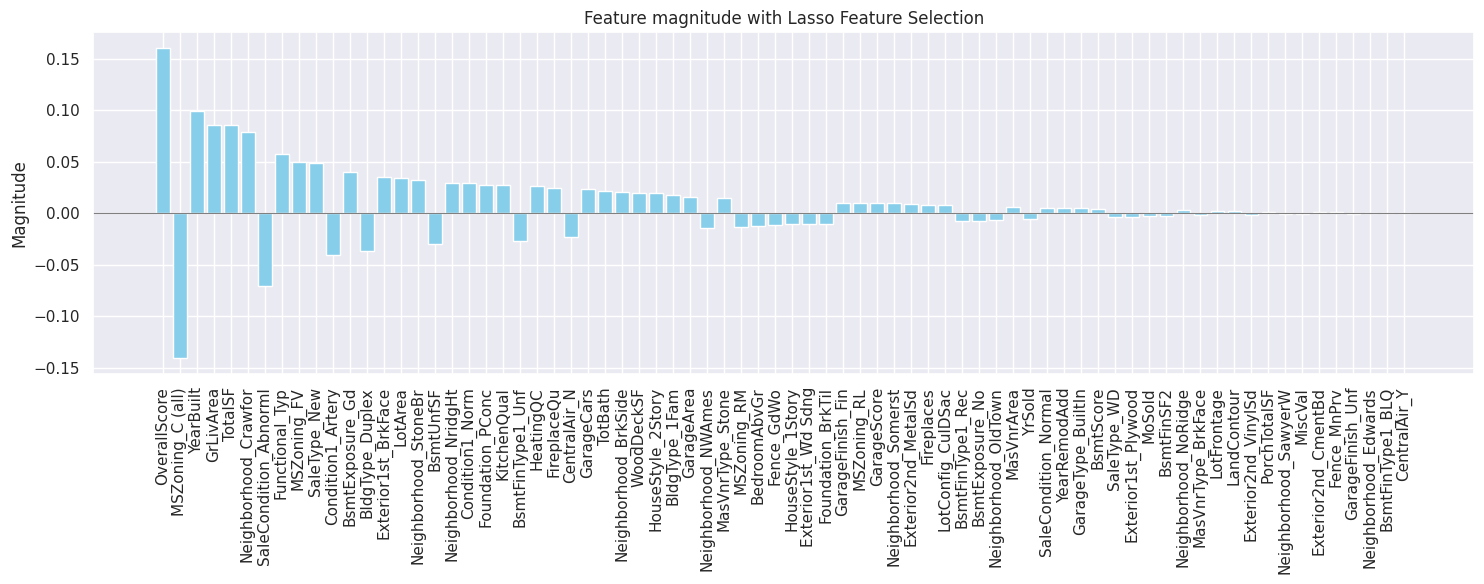

In [45]:
# Creating a Dataframe containing the importance for each feature
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": coefficients
})

#Here we filter only for features whose importance is different from 0
coef_df = coef_df[coef_df["Importance"] != 0]

#Now we sort the values
coef_df = coef_df.reindex(coef_df["Importance"].abs().sort_values(ascending=False).index)

#Plot
plt.figure(figsize=(15,6))
bars = plt.bar(coef_df["Feature"], coef_df["Importance"], color='skyblue')
plt.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=90)
plt.title("Feature magnitude with Lasso Feature Selection")
plt.ylabel("Magnitude")
plt.tight_layout()
plt.show()


In [46]:
coef_df.Feature

236            OverallScore
7          MSZoning_C (all)
213               YearBuilt
220               GrLivArea
233                 TotalSF
               ...         
187             Fence_MnPrv
181        GarageFinish_Unf
29     Neighborhood_Edwards
137        BsmtFinType1_BLQ
157            CentralAir_Y
Name: Feature, Length: 74, dtype: object

### Dataset Overview

- `X` contains the **entire training dataset** (including features and targets used for model training and validation).
- `X_sub` contains the **test dataset** (features only), used for final predictions and submission.

### Train-Test Split (from `X`)

We further split `X` into:

- `X_train`: used to **train** the model.
- `X_test`: used to **evaluate** the model performance during development


In [47]:
lasso_features=coef_df.Feature
X_train_selected_lasso = X_train[lasso_features]
X_test_selected_lasso = X_test[lasso_features]
X_selected_lasso = X[lasso_features]
X_sub_lasso=X_sub[coef_df.Feature]

## Feature Selection with RFE

In [48]:
model_sel = LinearRegression()
selector = RFE(model_sel, n_features_to_select=70)
selector.fit(X_train, y_train)

rfe_features = X.columns[selector.support_]

In [49]:
print(rfe_features)

Index(['MSZoning_C (all)', 'MSZoning_FV', 'Street_Grvl', 'Alley_Pave',
       'LotConfig_FR3', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_Crawfor', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_SWISU', 'Neighborhood_StoneBr', 'Condition1_Artery',
       'Condition1_RRAe', 'Condition1_RRNn', 'Condition2_Feedr',
       'Condition2_PosA', 'RoofStyle_Gable', 'RoofStyle_Hip',
       'RoofStyle_Mansard', 'RoofStyle_Shed', 'RoofMatl_WdShake',
       'Exterior1st_BrkComm', 'Exterior1st_BrkFace', 'Exterior1st_Stone',
       'Exterior1st_Wd Sdng', 'Exterior2nd_CmentBd', 'Exterior2nd_Other',
       'Exterior2nd_Wd Sdng', 'Foundation_Stone', 'Foundation_Wood',
       'BsmtExposure_No', 'BsmtExposure_None', 'BsmtFinType1_None',
       'BsmtFinType2_BLQ', 'BsmtFinType2_None', 'Heating_GasA', 'Heating_GasW',
       'Heating_Wall', 'CentralAir_Y', 'Electrical_FuseF', 'Electric

In [50]:
X_train_selected_rfe=X_train[rfe_features]
X_test_selected_rfe = X_test[rfe_features]
X_selected_rfe = X[rfe_features]
X_sub_rfe = X_sub[rfe_features]
print(X_selected_rfe.shape)

(1458, 70)


## Looking for the best subset of features

In [51]:
results_lasso = run_grid_search(models_to_grid, X_train_selected_lasso, y_train)

 Performing GridSearchCV for Lasso
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Lasso: RMSE = 0.0958
 Performing GridSearchCV for Ridge
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Ridge: RMSE = 0.0958
 Performing GridSearchCV for Elastic Net
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Elastic Net: RMSE = 0.0958
 Performing GridSearchCV for Decision Tree Regressor
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Decision Tree Regressor: RMSE = 0.1647
 Performing GridSearchCV for SVR
Fitting 3 folds for each of 20 candidates, totalling 60 fits
SVR: RMSE = 0.1775
 Performing GridSearchCV for Gradient Boosting
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Gradient Boosting: RMSE = 0.0691
 Performing GridSearchCV for XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost: RMSE = 0.0319


In [52]:
results_rfe = run_grid_search(models_to_grid, X_train_selected_rfe, y_train)

 Performing GridSearchCV for Lasso
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Lasso: RMSE = 0.0965
 Performing GridSearchCV for Ridge
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Ridge: RMSE = 0.0969
 Performing GridSearchCV for Elastic Net
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Elastic Net: RMSE = 0.0962
 Performing GridSearchCV for Decision Tree Regressor
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Decision Tree Regressor: RMSE = 0.1830
 Performing GridSearchCV for SVR
Fitting 3 folds for each of 20 candidates, totalling 60 fits
SVR: RMSE = 0.2093
 Performing GridSearchCV for Gradient Boosting
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Gradient Boosting: RMSE = 0.0699
 Performing GridSearchCV for XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost: RMSE = 0.0456


### Feature Selection with Lasso

It appears that **Lasso** performed effective feature selection by eliminating less important features.

From this point forward, we will proceed using only the features **retained by Lasso**, as they are likely the most relevant for our predictive task.


In [53]:
params_lasso = results_lasso["Lasso"]["best_params"]
model_lasso = Lasso(**params_lasso)

params_ridge = results_lasso["Ridge"]["best_params"]
model_ridge = Ridge(**params_ridge)

params_elastic = results_lasso["Elastic Net"]["best_params"]
model_elastic = ElasticNet(**params_elastic)

params_svr = results_lasso["SVR"]["best_params"]
model_svr = SVR(**params_svr)

params_gbr = results_lasso["Gradient Boosting"]["best_params"]
model_gbr = GradientBoostingRegressor(**params_gbr)

params_xgb = results_lasso["XGBoost"]["best_params"]
model_xgb = XGBRegressor(**params_xgb)


In [54]:
model_lasso.fit(X_selected_lasso,y)
model_ridge.fit(X_selected_lasso,y)
model_elastic.fit(X_selected_lasso,y)
model_svr.fit(X_selected_lasso,y)
model_gbr.fit(X_selected_lasso,y)
model_xgb.fit(X_selected_lasso,y)

LGBMRegressor(bagging_fraction=0.75, bagging_freq=5, bagging_seed=7,
              feature_fraction=0.2, feature_fraction_seed=7, learning_rate=0.01,
              max_bin=200, n_estimators=5000, num_leaves=4,
              objective='regression', verbose=-1)

In [55]:
y_pred_lasso = model_lasso.predict(X_sub_lasso)
y_pred_ridge = model_ridge.predict(X_sub_lasso)
y_pred_elastic = model_elastic.predict(X_sub_lasso)
y_pred_svr = model_svr.predict(X_sub_lasso)
y_pred_gbr = model_gbr.predict(X_sub_lasso)
y_pred_xgb = model_xgb.predict(X_sub_lasso)

In [56]:
y_pred=(y_pred_lasso + y_pred_ridge + y_pred_elastic + y_pred_svr + y_pred_gbr + y_pred_xgb)/6

In [57]:
print('Predict submission')
submission = pd.read_csv("./submission.csv")
submission.iloc[:,1] = np.floor(np.expm1(y_pred))
submission.to_csv("submission_mio.csv", index=False)

Predict submission


### Dimensionality Reduction with PCA

In [58]:
print(X_train_selected_lasso.shape)
pca=PCA(n_components=0.99)
X_reduced = pca.fit_transform(X_selected_lasso)
X_sub_reduced=pca.transform(X_sub_lasso)
print(X_reduced.shape)
print(X_sub_reduced.shape)

(972, 74)
(1458, 44)
(1459, 44)


In [59]:
params_lasso = results_lasso["Lasso"]["best_params"]
model_lasso = Lasso(**params_lasso)

params_ridge = results_lasso["Ridge"]["best_params"]
model_ridge = Ridge(**params_ridge)

params_elastic = results_lasso["Elastic Net"]["best_params"]
model_elastic = ElasticNet(**params_elastic)

params_dt = results_lasso["Decision Tree Regressor"]["best_params"]
model_dt = DecisionTreeRegressor(**params_dt)

params_gbr = results_lasso["Gradient Boosting"]["best_params"]
model_gbr = GradientBoostingRegressor(**params_gbr)

params_xgb = results_lasso["XGBoost"]["best_params"]
model_xgb = XGBRegressor(**params_xgb)


In [46]:
model_lasso.fit(X_reduced,y)
model_ridge.fit(X_reduced,y)
model_elastic.fit(X_reduced,y)
model_gbr.fit(X_reduced,y)
model_xgb.fit(X_reduced,y)

NameError: name 'model_lasso' is not defined

In [61]:
y_pred_lasso = model_lasso.predict(X_sub_reduced)
y_pred_ridge = model_ridge.predict(X_sub_reduced)
y_pred_elastic = model_elastic.predict(X_sub_reduced)
y_pred_gbr = model_gbr.predict(X_sub_reduced)
y_pred_xgb = model_xgb.predict(X_sub_reduced)

In [62]:
y_pred=(y_pred_lasso + y_pred_ridge + y_pred_elastic + y_pred_gbr + y_pred_xgb)/5

In [63]:
print('Predict submission')
submission = pd.read_csv("./submission.csv")
submission.iloc[:,1] = np.floor(np.expm1(y_pred))
submission.to_csv("submission_mio.csv", index=False)

Predict submission


# Hyper-parameters fine tuning

In [ ]:
results_lasso

In [64]:
def objective_lasso(trial):
    # Define the search space
    alpha = trial.suggest_loguniform('alpha', 1e-5, 1e-3)
    
    model = Lasso(alpha=alpha,random_state=1)

    score = cross_val_score(model, X_selected_lasso, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score

def objective_ridge(trial):
    # Define the search space
    alpha = trial.suggest_loguniform('alpha', 1e-1, 10)
    
    model = Ridge(alpha=alpha,random_state=1)

    score = cross_val_score(model, X_selected_lasso, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score

def objective_elastic(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 1e-2)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=3, max_iter=10000)

    score = cross_val_score(model, X_selected_lasso, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score


def objective_gb(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
    }
    
    model = GradientBoostingRegressor(**param)
    score = cross_val_score(model, X_selected_lasso, y, cv=5, scoring='neg_root_mean_squared_error', error_score='raise',n_jobs=-1).mean()
    return -score

def objective_xgb(trial):
    param = {
            'n_estimators': trial.suggest_int('n_estimators',100,5000),
            'learning_rate': trial.suggest_float('learning_rate',0.01,0.2),
            'max_depth': trial.suggest_int('max_depth',2,10),
            'subsample': trial.suggest_float('subsample',0.5,1),
            'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,1),
            'gamma': trial.suggest_float('gamma',0,0.5)
        
    }
    model = XGBRegressor(**param)
    score = cross_val_score(model, X_selected_lasso, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    return -score
    

In [65]:
study_lasso_tpe = optuna.create_study(study_name='lasso_tpe', direction='minimize',
                            sampler=optuna.samplers.TPESampler())

[I 2025-07-06 23:22:59,878] A new study created in memory with name: lasso_tpe


In [66]:
start_time = time.time()
study_lasso_tpe.optimize(objective_lasso, n_trials=300, show_progress_bar=True, n_jobs=-1)
end_time = time.time()
execution_time_lasso = end_time - start_time
print(f'\n\n\n\nExecution time: {execution_time_lasso:.2f} secs')
print(f'Best rmse score: {study_lasso_tpe.best_value:.4f}')
print(f'Best hyperparameters: {study_lasso_tpe.best_params}')

  0%|          | 0/300 [00:00<?, ?it/s]

[I 2025-07-06 23:23:00,083] Trial 1 finished with value: 0.10815744331359874 and parameters: {'alpha': 0.000777478400876772}. Best is trial 1 with value: 0.10815744331359874.
[I 2025-07-06 23:23:00,129] Trial 0 finished with value: 0.10713302208199808 and parameters: {'alpha': 1.396420072319316e-05}. Best is trial 0 with value: 0.10713302208199808.
[I 2025-07-06 23:23:00,155] Trial 3 finished with value: 0.10658125126169497 and parameters: {'alpha': 0.00019496966607265127}. Best is trial 3 with value: 0.10658125126169497.
[I 2025-07-06 23:23:00,170] Trial 2 finished with value: 0.1070977212835218 and parameters: {'alpha': 2.0015170584902568e-05}. Best is trial 3 with value: 0.10658125126169497.
[I 2025-07-06 23:23:00,221] Trial 5 finished with value: 0.1069636711861413 and parameters: {'alpha': 4.7554443052092077e-05}. Best is trial 3 with value: 0.10658125126169497.
[I 2025-07-06 23:23:00,231] Trial 7 finished with value: 0.10708053883323695 and parameters: {'alpha': 2.29755902793001e

[I 2025-07-06 23:23:01,432] Trial 52 finished with value: 0.1067080257320396 and parameters: {'alpha': 0.00012416891035289782}. Best is trial 15 with value: 0.10657435923404715.
[I 2025-07-06 23:23:01,441] Trial 54 finished with value: 0.10684008901647998 and parameters: {'alpha': 7.951086563399508e-05}. Best is trial 15 with value: 0.10657435923404715.
[I 2025-07-06 23:23:01,500] Trial 53 finished with value: 0.10685350945470296 and parameters: {'alpha': 7.566201152204346e-05}. Best is trial 15 with value: 0.10657435923404715.
[I 2025-07-06 23:23:01,512] Trial 56 finished with value: 0.10663727649323207 and parameters: {'alpha': 0.000311812538320498}. Best is trial 15 with value: 0.10657435923404715.
[I 2025-07-06 23:23:01,548] Trial 55 finished with value: 0.10688603235461339 and parameters: {'alpha': 6.70634711879964e-05}. Best is trial 15 with value: 0.10657435923404715.
[I 2025-07-06 23:23:01,591] Trial 57 finished with value: 0.10657112787288181 and parameters: {'alpha': 0.000223

[I 2025-07-06 23:23:02,821] Trial 108 finished with value: 0.10663931610769901 and parameters: {'alpha': 0.00015817193868209535}. Best is trial 70 with value: 0.1065689561141199.
[I 2025-07-06 23:23:02,867] Trial 110 finished with value: 0.10662590267966265 and parameters: {'alpha': 0.00016577728193967826}. Best is trial 70 with value: 0.1065689561141199.
[I 2025-07-06 23:23:02,879] Trial 109 finished with value: 0.10660971988194705 and parameters: {'alpha': 0.00017584739110945976}. Best is trial 70 with value: 0.1065689561141199.
[I 2025-07-06 23:23:02,893] Trial 111 finished with value: 0.10664389615585552 and parameters: {'alpha': 0.0001556419891426006}. Best is trial 70 with value: 0.1065689561141199.
[I 2025-07-06 23:23:02,945] Trial 114 finished with value: 0.10664073047505973 and parameters: {'alpha': 0.00015738208673129277}. Best is trial 70 with value: 0.1065689561141199.
[I 2025-07-06 23:23:02,950] Trial 112 finished with value: 0.10657617977763559 and parameters: {'alpha': 0

[I 2025-07-06 23:23:04,157] Trial 158 finished with value: 0.10657083446661968 and parameters: {'alpha': 0.0002226430508854517}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:04,175] Trial 160 finished with value: 0.10657116533207027 and parameters: {'alpha': 0.00022358993830729314}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:04,198] Trial 161 finished with value: 0.10657196412007612 and parameters: {'alpha': 0.0002251603219614383}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:04,233] Trial 162 finished with value: 0.10657055092266439 and parameters: {'alpha': 0.0002217499289599293}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:04,266] Trial 163 finished with value: 0.10657446065101413 and parameters: {'alpha': 0.00023203798787346832}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:04,275] Trial 164 finished with value: 0.10657123405509998 and parameters: {'a

[I 2025-07-06 23:23:05,478] Trial 210 finished with value: 0.1065882295919385 and parameters: {'alpha': 0.000258306314732255}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:05,535] Trial 211 finished with value: 0.1065692000076505 and parameters: {'alpha': 0.00021722701296033255}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:05,554] Trial 213 finished with value: 0.10657019351308505 and parameters: {'alpha': 0.00022058724555493734}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:05,590] Trial 215 finished with value: 0.10657040567416534 and parameters: {'alpha': 0.00022128242393364616}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:05,598] Trial 212 finished with value: 0.1065703401095794 and parameters: {'alpha': 0.00022106873300277273}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:05,621] Trial 214 finished with value: 0.10656939791078576 and parameters: {'alp

[I 2025-07-06 23:23:06,857] Trial 261 finished with value: 0.10657850874484572 and parameters: {'alpha': 0.00019738162169340945}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:06,864] Trial 263 finished with value: 0.10658968342058806 and parameters: {'alpha': 0.00018888078758566858}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:06,899] Trial 265 finished with value: 0.10662409225786232 and parameters: {'alpha': 0.00030025729720150127}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:06,912] Trial 264 finished with value: 0.10661551319947464 and parameters: {'alpha': 0.0002915688245601306}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:06,928] Trial 267 finished with value: 0.10659762063662281 and parameters: {'alpha': 0.00018350387991076232}. Best is trial 159 with value: 0.10656885313237555.
[I 2025-07-06 23:23:06,953] Trial 268 finished with value: 0.10662165926868421 and parameters: {

In [67]:
study_ridge_tpe = optuna.create_study(study_name='ridge_tpe', direction='minimize',
                            sampler=optuna.samplers.TPESampler())

[I 2025-07-06 23:23:07,767] A new study created in memory with name: ridge_tpe


In [68]:
start_time = time.time()
study_ridge_tpe.optimize(objective_ridge, n_trials=100, show_progress_bar=True, n_jobs=-1)
end_time = time.time()
execution_time_lasso = end_time - start_time
print(f'\n\n\n\nExecution time: {execution_time_lasso:.2f} secs')
print(f'Best rmse score: {study_ridge_tpe.best_value:.4f}')
print(f'Best hyperparameters: {study_ridge_tpe.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-07-06 23:23:07,869] Trial 0 finished with value: 0.10718228819725617 and parameters: {'alpha': 0.13212842112771686}. Best is trial 0 with value: 0.10718228819725617.
[I 2025-07-06 23:23:07,898] Trial 3 finished with value: 0.10769458773863927 and parameters: {'alpha': 8.185367446148947}. Best is trial 0 with value: 0.10718228819725617.
[I 2025-07-06 23:23:07,901] Trial 1 finished with value: 0.10768461979569462 and parameters: {'alpha': 8.09217457441666}. Best is trial 0 with value: 0.10718228819725617.
[I 2025-07-06 23:23:07,920] Trial 7 finished with value: 0.1071590903377972 and parameters: {'alpha': 0.2345441785754413}. Best is trial 7 with value: 0.1071590903377972.
[I 2025-07-06 23:23:07,950] Trial 2 finished with value: 0.10711228994717556 and parameters: {'alpha': 0.5352894604588855}. Best is trial 2 with value: 0.10711228994717556.
[I 2025-07-06 23:23:07,957] Trial 5 finished with value: 0.10717880421237347 and parameters: {'alpha': 0.14631897896667756}. Best is trial 

[I 2025-07-06 23:23:08,947] Trial 48 finished with value: 0.10713982397898461 and parameters: {'alpha': 2.6543238495127155}. Best is trial 39 with value: 0.10707795549865454.
[I 2025-07-06 23:23:08,977] Trial 51 finished with value: 0.1071296852783838 and parameters: {'alpha': 2.5126639937458752}. Best is trial 39 with value: 0.10707795549865454.
[I 2025-07-06 23:23:09,002] Trial 49 finished with value: 0.10710451405360592 and parameters: {'alpha': 2.1119266530348355}. Best is trial 39 with value: 0.10707795549865454.
[I 2025-07-06 23:23:09,014] Trial 50 finished with value: 0.10714186020445424 and parameters: {'alpha': 2.6818780311485475}. Best is trial 39 with value: 0.10707795549865454.
[I 2025-07-06 23:23:09,025] Trial 52 finished with value: 0.10714533148082232 and parameters: {'alpha': 2.7282489367690657}. Best is trial 39 with value: 0.10707795549865454.
[I 2025-07-06 23:23:09,071] Trial 53 finished with value: 0.1071902017385699 and parameters: {'alpha': 0.10121538880379424}. B

[I 2025-07-06 23:23:10,036] Trial 99 finished with value: 0.10708430614339226 and parameters: {'alpha': 1.6548549302253932}. Best is trial 93 with value: 0.10707764894374117.




Execution time: 2.26 secs
Best rmse score: 0.1071
Best hyperparameters: {'alpha': 1.266994298878688}


In [69]:
study_elastic_tpe = optuna.create_study(study_name='elastic_tpe', direction='minimize',
                            sampler=optuna.samplers.TPESampler())

[I 2025-07-06 23:23:10,048] A new study created in memory with name: elastic_tpe


In [70]:
start_time = time.time()
study_elastic_tpe.optimize(objective_elastic, n_trials=100, show_progress_bar=True, n_jobs=-1)
end_time = time.time()
execution_time_elastic = end_time - start_time
print(f'\n\n\n\nExecution time: {execution_time_elastic:.2f} secs')
print(f'Best rmse score: {study_elastic_tpe.best_value:.4f}')
print(f'Best hyperparameters: {study_elastic_tpe.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-07-06 23:23:10,192] Trial 0 finished with value: 0.10671633332749937 and parameters: {'alpha': 0.0007725103721093992, 'l1_ratio': 0.21000147549898449}. Best is trial 0 with value: 0.10671633332749937.
[I 2025-07-06 23:23:10,214] Trial 2 finished with value: 0.10724855304819006 and parameters: {'alpha': 0.0006686637048604301, 'l1_ratio': 0.82358401104435}. Best is trial 0 with value: 0.10671633332749937.
[I 2025-07-06 23:23:10,225] Trial 1 finished with value: 0.10663346001442979 and parameters: {'alpha': 0.0004905568179087751, 'l1_ratio': 0.4549101880707179}. Best is trial 1 with value: 0.10663346001442979.
[I 2025-07-06 23:23:10,250] Trial 3 finished with value: 0.11856835602346498 and parameters: {'alpha': 0.005778653793666178, 'l1_ratio': 0.540792116617613}. Best is trial 1 with value: 0.10663346001442979.
[I 2025-07-06 23:23:10,272] Trial 5 finished with value: 0.10697709683395136 and parameters: {'alpha': 0.001922759860596794, 'l1_ratio': 0.10031632786185973}. Best is tria

[I 2025-07-06 23:23:11,345] Trial 39 finished with value: 0.10725527487217676 and parameters: {'alpha': 0.0008843818830180915, 'l1_ratio': 0.5897161487064011}. Best is trial 21 with value: 0.10658924689874902.
[I 2025-07-06 23:23:11,370] Trial 41 finished with value: 0.10691213673508042 and parameters: {'alpha': 0.0006875325472775646, 'l1_ratio': 0.5988835757891126}. Best is trial 21 with value: 0.10658924689874902.
[I 2025-07-06 23:23:11,391] Trial 43 finished with value: 0.10711169405459309 and parameters: {'alpha': 0.0006184193180986889, 'l1_ratio': 0.8270039506644892}. Best is trial 21 with value: 0.10658924689874902.
[I 2025-07-06 23:23:11,408] Trial 42 finished with value: 0.1069952298923513 and parameters: {'alpha': 0.0005760161074821102, 'l1_ratio': 0.8198064999827008}. Best is trial 21 with value: 0.10658924689874902.
[I 2025-07-06 23:23:11,486] Trial 44 finished with value: 0.10699513493233903 and parameters: {'alpha': 0.0005675112143287582, 'l1_ratio': 0.8346933602461033}. B

[I 2025-07-06 23:23:12,698] Trial 86 finished with value: 0.10657937930663866 and parameters: {'alpha': 0.0002619040541162309, 'l1_ratio': 0.8638981733871612}. Best is trial 83 with value: 0.10657557126255672.
[I 2025-07-06 23:23:12,707] Trial 87 finished with value: 0.10661471440970696 and parameters: {'alpha': 0.0002603783136038287, 'l1_ratio': 0.6708223708016459}. Best is trial 83 with value: 0.10657557126255672.
[I 2025-07-06 23:23:12,786] Trial 88 finished with value: 0.10657984275580172 and parameters: {'alpha': 0.0002650285765836679, 'l1_ratio': 0.8506603664127387}. Best is trial 83 with value: 0.10657557126255672.
[I 2025-07-06 23:23:12,804] Trial 89 finished with value: 0.10657747650119961 and parameters: {'alpha': 0.00025792567911063973, 'l1_ratio': 0.8547993288705041}. Best is trial 83 with value: 0.10657557126255672.
[I 2025-07-06 23:23:12,833] Trial 91 finished with value: 0.10680068905848535 and parameters: {'alpha': 0.00010621284796087871, 'l1_ratio': 0.8611421056638568}

In [ ]:
study_light_tpe = optuna.create_study(study_name='light_tpe', direction='minimize',
                            sampler=optuna.samplers.TPESampler())

In [ ]:
start_time = time.time()
study_light_tpe.optimize(objective_lightgbm, n_trials=40, show_progress_bar=True, n_jobs=-1)
end_time = time.time()
execution_time_light = end_time - start_time
print(f'\n\n\n\nExecution time: {execution_time_light:.2f} secs')
print(f'Best rmse score: {study_light_tpe.best_value:.4f}')
print(f'Best hyperparameters: {study_light_tpe.best_params}')

In [ ]:
study_gb_tpe = optuna.create_study(study_name='gb_tpe', direction='minimize',
                            sampler=optuna.samplers.TPESampler())

In [ ]:
start_time = time.time()
study_gb_tpe.optimize(objective_gb, n_trials=40, show_progress_bar=True, n_jobs=-1)
end_time = time.time()
execution_time_light = end_time - start_time
print(f'\n\n\n\nExecution time: {execution_time_light:.2f} secs')
print(f'Best rmse score: {study_gb_tpe.best_value:.4f}')
print(f'Best hyperparameters: {study_gb_tpe.best_params}')

In [ ]:
study_xgb_tpe = optuna.create_study(study_name='xgb_tpe', direction='minimize',
                            sampler=optuna.samplers.TPESampler())

In [ ]:
start_time = time.time()
study_xgb_tpe.optimize(objective_xgb, n_trials=40, show_progress_bar=True, n_jobs=-1)
end_time = time.time()
execution_time_light = end_time - start_time
print(f'\n\n\n\nExecution time: {execution_time_light:.2f} secs')
print(f'Best rmse score: {study_xgb_tpe.best_value:.4f}')
print(f'Best hyperparameters: {study_xgb_tpe.best_params}')

In [ ]:
study_elastic_tpe.best_params

In [ ]:
params_lasso = study_lasso_tpe.best_params
model_lasso = Lasso(**params_lasso)

params_ridge = study_ridge_tpe.best_params
model_ridge = Ridge(**params_ridge)

params_elastic = study_elastic_tpe.best_params
model_elastic = ElasticNet(**params_elastic)


params_gbr = study_gb_tpe.best_params
model_gbr = GradientBoostingRegressor(**params_gbr)

params_xgb = study_xgb_tpe.best_params
model_xgb = XGBRegressor(**params_xgb)


In [ ]:
model_lasso.fit(X_selected_lasso,y)
model_ridge.fit(X_selected_lasso,y)
model_elastic.fit(X_selected_lasso,y)
model_gbr.fit(X_selected_lasso,y)
model_xgb.fit(X_selected_lasso,y)

In [ ]:
y_pred_lasso = model_lasso.predict(X_sub_lasso)
y_pred_ridge = model_ridge.predict(X_sub_lasso)
y_pred_elastic = model_elastic.predict(X_sub_lasso)
y_pred_dt = model_dt.predict(X_sub_lasso)
y_pred_gbr = model_gbr.predict(X_sub_lasso)
y_pred_xgb = model_xgb.predict(X_sub_lasso)

In [ ]:
y_pred=(y_pred_lasso + y_pred_ridge + y_pred_elastic + y_pred_gbr + y_pred_xgb + )/5

In [ ]:
print('Predict submission')
submission = pd.read_csv("./submission.csv")
submission.iloc[:,1] = np.floor(np.expm1(y_pred))
submission.to_csv("submission_mio.csv", index=False)

# Results

As the final model, we chose a **blending ensemble** composed of the following base regressors:

- `Lasso`
- `Ridge`
- `ElasticNet`
- `SVR`
- `GradientBoostingRegressor`
- `XGBRegressor`

All models are used with the **best hyperparameters obtained from Random Search**.

In [53]:
params_lasso = results_lasso["Lasso"]["best_params"]
model_lasso = Lasso(**params_lasso)

params_ridge = results_lasso["Ridge"]["best_params"]
model_ridge = Ridge(**params_ridge)

params_elastic = results_lasso["Elastic Net"]["best_params"]
model_elastic = ElasticNet(**params_elastic)

params_svr = results_lasso["SVR"]["best_params"]
model_svr = SVR(**params_svr)

params_gbr = results_lasso["Gradient Boosting"]["best_params"]
model_gbr = GradientBoostingRegressor(**params_gbr)

params_xgb = results_lasso["XGBoost"]["best_params"]
model_xgb = XGBRegressor(**params_xgb)


In [54]:
model_lasso.fit(X_selected_lasso,y)
model_ridge.fit(X_selected_lasso,y)
model_elastic.fit(X_selected_lasso,y)
model_svr.fit(X_selected_lasso,y)
model_gbr.fit(X_selected_lasso,y)
model_xgb.fit(X_selected_lasso,y)

LGBMRegressor(bagging_fraction=0.75, bagging_freq=5, bagging_seed=7,
              feature_fraction=0.2, feature_fraction_seed=7, learning_rate=0.01,
              max_bin=200, n_estimators=5000, num_leaves=4,
              objective='regression', verbose=-1)

In [55]:
y_pred_lasso = model_lasso.predict(X_sub_lasso)
y_pred_ridge = model_ridge.predict(X_sub_lasso)
y_pred_elastic = model_elastic.predict(X_sub_lasso)
y_pred_svr = model_svr.predict(X_sub_lasso)
y_pred_gbr = model_gbr.predict(X_sub_lasso)
y_pred_xgb = model_xgb.predict(X_sub_lasso)

In [56]:
y_pred=(y_pred_lasso + y_pred_ridge + y_pred_elastic + y_pred_svr + y_pred_gbr + y_pred_xgb)/6

In [57]:
print('Predict submission')
submission = pd.read_csv("./submission.csv")
submission.iloc[:,1] = np.floor(np.expm1(y_pred))
submission.to_csv("submission_mio.csv", index=False)

Predict submission


# Conclusion

## Conclusions

1. **Hyperparameter Tuning**: The hyperparameters obtained through **Random Search** actually performed better than those obtained using **Bayesian Optimization** in this particular case.

2. **Efficiency and Performance**: Despite not relying on powerful ensemble methods or heavy computational resources, the model achieved **excellent results**. The entire training pipeline runs in under a minute on a regular CPU, demonstrating the effectiveness of the **preprocessing pipeline**. Thanks to this, the solution ranked within the **top 10%** of the Kaggle leaderboard.

3. **Dimensionality Reduction (PCA)**: Applying **Principal Component Analysis (PCA)** did not improve model performance. In fact, it led to **lower scores** and **slower model fitting**, suggesting that PCA was not beneficial for this dataset.

4. **Feature Importance**: From the training of the **Lasso Regression** model, we observed that the most relevant features for predicting house prices are:
   - `OverallScore`
   - `GrLivArea`
   - `TotalSF`
   - `YearBuilt`
   - `Neighborhood`